# Dummy Prediction

In [1]:
import pandas as pd
import numpy as np

# Load data
train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv", low_memory=False)
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv", low_memory=False)

# Dummy prediction — mean of target
mean_value = train['TargetValue'].mean()

submission = pd.DataFrame({
    'TransactionID': test['TransactionID'],
    'TargetValue': mean_value
})

submission.to_csv('submission.csv', index=False)
print(submission.head())
print("Shape:", submission.shape)

   TransactionID   TargetValue
0        1139307  41521.874047
1        1139419  41521.874047
2        1139482  41521.874047
3        1139522  41521.874047
4        1139684  41521.874047
Shape: (15000, 2)


In [2]:
help(pd)

Help on package pandas:

NAME
    pandas

DESCRIPTION
    pandas - a powerful data analysis and manipulation library for Python

    **pandas** is a Python package providing fast, flexible, and expressive data
    structures designed to make working with "relational" or "labeled" data both
    easy and intuitive. It aims to be the fundamental high-level building block for
    doing practical, **real world** data analysis in Python. Additionally, it has
    the broader goal of becoming **the most powerful and flexible open source data
    analysis / manipulation tool available in any language**. It is already well on
    its way toward this goal.

    Main Features
    -------------
    Here are just a few of the things that pandas does well:

      - Easy handling of missing data in floating point as well as non-floating
        point data.
      - Size mutability: columns can be inserted and deleted from DataFrame and
        higher dimensional objects
      - Automatic and explicit d

# LOAD DATA

In [3]:
import pandas as pd
import numpy as np
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')
print("Train Shape: ", train.shape)
print("Test Shape: ", test.shape)
train.head()

/tmp/ipykernel_16/3121790434.py:3: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')


Train Shape:  (138701, 50)
Test Shape:  (15000, 49)


,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


Lets Look at what we are predicting

count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64


<Axes: >

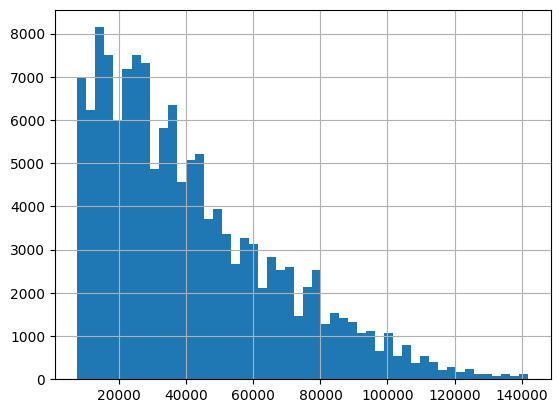

In [4]:
print(train['TargetValue'].describe())
train['TargetValue'].hist(bins=50) #builtin to pd

Using .describe() we get all statistical parameters like mean, stdev, Q1, Q2, Q3 and max. Using this we get a histogram clearly indicating that this is right skewed histogram, where lot of cheap machinery is being sold whereas there are only few machines driving the mean cost up, but the stdev is low to explain the right skewedness.

Let us try to model it around log(1+x) and see if we get a bell shaped curve.

<Axes: >

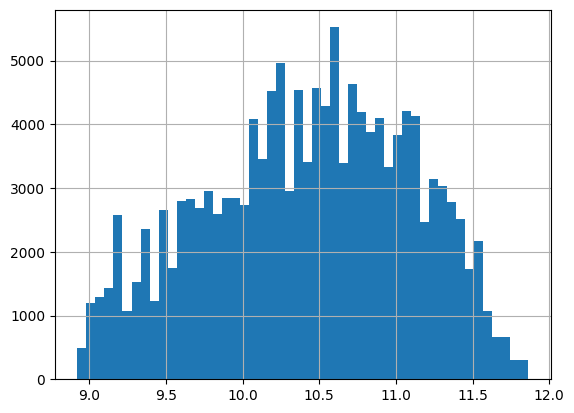

In [5]:
train['LogTarget']=np.log1p(train['TargetValue'])
train['LogTarget'].hist(bins=50)

Much more bell shaped looking, Models love predicting bell shaped curves. So lets use this to model the dataset

# EDA

There is a lot of data in the train.csv that are heavily missing Eg: Col 18 and 19 are empty and almost a dozen more are not applicable/some columns have something that is not applicable this is not bad data it is just that we can say that this particular specification is not applicable to our model.
Let us find missing values first.

## Missing Values Overview

In [6]:
missing_val = train.isnull().mean().sort_values(ascending=False)*100
print(missing_val.head(20))

col19                 99.952416
col18                 99.952416
col5                  92.515555
col4                  92.515555
col27                 89.214930
col28                 89.214930
col29                 86.393753
col30                 86.393753
col13                 83.125572
col14                 83.125572
col9                  83.125572
col11                 83.125572
col6                  83.125572
col8                  83.125572
col7                  83.125572
col3                  78.909309
Forks                 78.861724
Spec_ReleaseSeries    76.282795
col1                  75.641127
col12                 72.340502
dtype: float64


We have found the top 20 rows with most missing values.

Now lets see some bad years.

## Manufacture Year & Asset Age

In [7]:
print(train['ManufactureYear'].describe())

print("Suspiciously old years: ")
print(train[train['ManufactureYear']<1950]['ManufactureYear'].value_counts())
print(test[test['ManufactureYear']<1950]['ManufactureYear'].value_counts())


count    138701.000000
mean       1891.640853
std         306.992001
min        1001.000000
25%        1990.000000
50%        1998.000000
75%        2004.000000
max        2015.000000
Name: ManufactureYear, dtype: float64
Suspiciously old years: 
ManufactureYear
1001    14719
1920       13
1921        7
1949        1
Name: count, dtype: int64
ManufactureYear
1001    1580
1921       2
Name: count, dtype: int64


There are 14791 values with manufacturing year as 1001 that is just a placeholder for unknown year we can assume. Similarly under test also it is a placeholder for unknown years

Let us find the relationship between the age of the machine and the selling price.

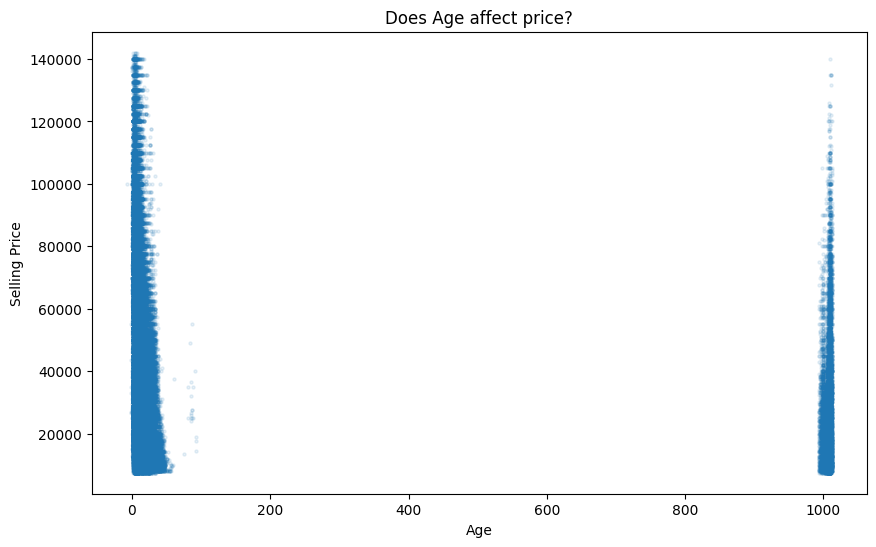

In [8]:
train['TransactionDate']=pd.to_datetime(train['TransactionDate'])
train['SaleYear']=train['TransactionDate'].dt.year
train['Age']=train['SaleYear']-train['ManufactureYear']

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(train['Age'], train['TargetValue'], alpha=0.1, s=5)
plt.xlabel("Age")
plt.ylabel("Selling Price")
plt.title("Does Age affect price?")
plt.show()

## Machine Type (InventoryGroupDescription)

Inventory Group Description

In [9]:
print(train['InventoryGroupDescription'].value_counts())
train['InventoryGroupDescription'].value_counts().sum()

InventoryGroupDescription
Track Excavators       71018
Motor Graders          23405
Wheel Loader           18872
Track Type Tractors    14959
Backhoe Loaders        10381
Skid Steer Loaders        66
Name: count, dtype: int64


np.int64(138701)

Clearly more than half of the dataset is dominated by track excavators so we tend to see more track excavators than any other type while modelling. Skid steer loaders are just 0.05% there is very little we can learn from that type.

Let us split the inventories to 6 and find their mean selling price

In [10]:
print(train.groupby('InventoryGroupDescription')['TargetValue'].mean().sort_values(ascending=False))
train['InventoryGroupDescription'].value_counts() #for comparison sake

InventoryGroupDescription
Track Type Tractors    48733.741239
Motor Graders          47722.283828
Wheel Loader           46468.955331
Track Excavators       39281.266299
Backhoe Loaders        23649.794721
Skid Steer Loaders     15602.272727
Name: TargetValue, dtype: float64


InventoryGroupDescription
Track Excavators       71018
Motor Graders          23405
Wheel Loader           18872
Track Type Tractors    14959
Backhoe Loaders        10381
Skid Steer Loaders        66
Name: count, dtype: int64

By looking at images on google and seeing their size it starts making sense their selling prices are directly depending on their sizes.

Clearly one with lower selling price is being sold more and the ones with higher not being sold as much.

## Region Code

Lets check region code.

In [11]:
print(train['RegionCode'].value_counts())

RegionCode
Florida           23460
Texas             18284
California         9525
Washington         6063
Georgia            5240
North Carolina     4391
Maryland           4352
Mississippi        4227
Colorado           3989
Illinois           3855
Alabama            3723
Tennessee          3602
Ohio               3528
South Carolina     3386
New Jersey         3370
Arizona            3102
Connecticut        2860
Nevada             2730
Missouri           2531
Pennsylvania       2406
Minnesota          2377
Louisiana          2230
New York           2111
Utah               1518
Kentucky           1469
New Mexico         1360
Arkansas           1359
Indiana            1100
Virginia            941
Maine               928
Michigan            846
New Hampshire       822
Wisconsin           754
Idaho               742
Iowa                618
Oregon              603
Unspecified         586
Oklahoma            578
West Virginia       571
Montana             497
Wyoming             467
Nebra

In [12]:
print(train.groupby('RegionCode')['TargetValue'].mean().sort_values(ascending=False))

RegionCode
South Dakota      54628.455285
Rhode Island      52992.857143
Unspecified       51705.631399
Nevada            47533.589744
Alabama           47471.214343
North Dakota      46017.015707
West Virginia     45270.577933
Florida           45007.542626
Mississippi       44990.111190
Georgia           44501.412214
Texas             44341.440713
Arizona           43524.403611
Nebraska          43438.772846
New Mexico        43424.448529
Colorado          43261.847581
Montana           42987.826962
Oklahoma          41764.013841
Iowa              41507.443366
Kentucky          41375.221239
Utah              41220.520422
North Carolina    40894.505807
New Jersey        40643.442136
Tennessee         40526.012771
Arkansas          40501.565857
Delaware          40421.259843
South Carolina    40081.969876
Louisiana         39819.708520
Virginia          39421.572795
Wyoming           39124.464668
Missouri          39100.201501
Minnesota         39018.111064
Illinois          38724.4228

Region shows price variation, but extreme values (highest and lowest) come from states with very few sales (eg: Washington DC: 2 rows, Puerto Rico: 11 rows). These averages are unreliable due to small sample size. States with large sample sizes (Florida, Texas, California) show more moderate, trustworthy price differences, suggesting region has a real but modest effect on price compared to machine type.

## Spec Column Missingness (col4, col18)

Let us see the missing values once again to check them

In [13]:
miss_pct = train.isnull().mean().sort_values(ascending=False)
print(miss_pct.head(40))

col19                        0.999524
col18                        0.999524
col4                         0.925156
col5                         0.925156
col27                        0.892149
col28                        0.892149
col29                        0.863938
col30                        0.863938
col13                        0.831256
col7                         0.831256
col6                         0.831256
col11                        0.831256
col14                        0.831256
col8                         0.831256
col9                         0.831256
col3                         0.789093
Forks                        0.788617
Spec_ReleaseSeries           0.762828
col1                         0.756411
col12                        0.723405
col15                        0.695193
DrivetrainType               0.648561
UtilizationTier              0.636088
Spec_VariantModifier         0.622699
col25                        0.487992
col20                        0.487992
col21       

Check col4 and see if it lines up with our expectations.

In [14]:
train['col4_missing']=train['col4'].isnull()
print(train.groupby('InventoryGroupDescription')['col4_missing'].mean())
print(train.groupby('col4_missing')['TargetValue'].mean())
train.head()

InventoryGroupDescription
Backhoe Loaders        0.0
Motor Graders          1.0
Skid Steer Loaders     1.0
Track Excavators       1.0
Track Type Tractors    1.0
Wheel Loader           1.0
Name: col4_missing, dtype: float64
col4_missing
False    23649.794721
True     42967.713008
Name: TargetValue, dtype: float64


,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col24,col25,col27,col28,col29,col30,LogTarget,SaleYear,Age,col4_missing
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,Standard,Conventional,10.950824,2005,8,True
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,10.184938,2009,4,False
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,None or Unspecified,Double,NaN,NaN,NaN,NaN,9.952325,2005,11,True
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,10.203629,2006,4,False
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,None or Unspecified,Double,NaN,NaN,NaN,NaN,9.975855,2010,1,True


Every Backhoe Loader has col4.
Every other machine type does not have col4.
So probably col4 is a feature is a Backhoe Loader
So col4 is not randomly missing it just doesnt apply to the spec so we cant ignore col4.

col18

In [15]:
train['col18_present']=train['col18'].notnull()
print(train.groupby('InventoryGroupDescription')['col18_present'].mean())
print(train['col18'].value_counts())
print(train.groupby('col18_present')['TargetValue'].mean())

InventoryGroupDescription
Backhoe Loaders        0.0
Motor Graders          0.0
Skid Steer Loaders     1.0
Track Excavators       0.0
Track Type Tractors    0.0
Wheel Loader           0.0
Name: col18_present, dtype: float64
col18
None or Unspecified    57
Yes                     9
Name: count, dtype: int64
col18_present
False    41534.213598
True     15602.272727
Name: TargetValue, dtype: float64


Only applicable for skid steer loaders

In [16]:
corr = train.corr(numeric_only=True)

corr["LogTarget"].sort_values(ascending=False)

LogTarget                1.000000
TargetValue              0.940826
ManufactureYear          0.233624
col4_missing             0.175208
OperationalHoursMeter    0.005228
ProductConfigID         -0.001218
TransactionID           -0.022812
SaleYear                -0.024602
col18_present           -0.025594
Age                     -0.233866
AssetID                 -0.236165
Name: LogTarget, dtype: float64

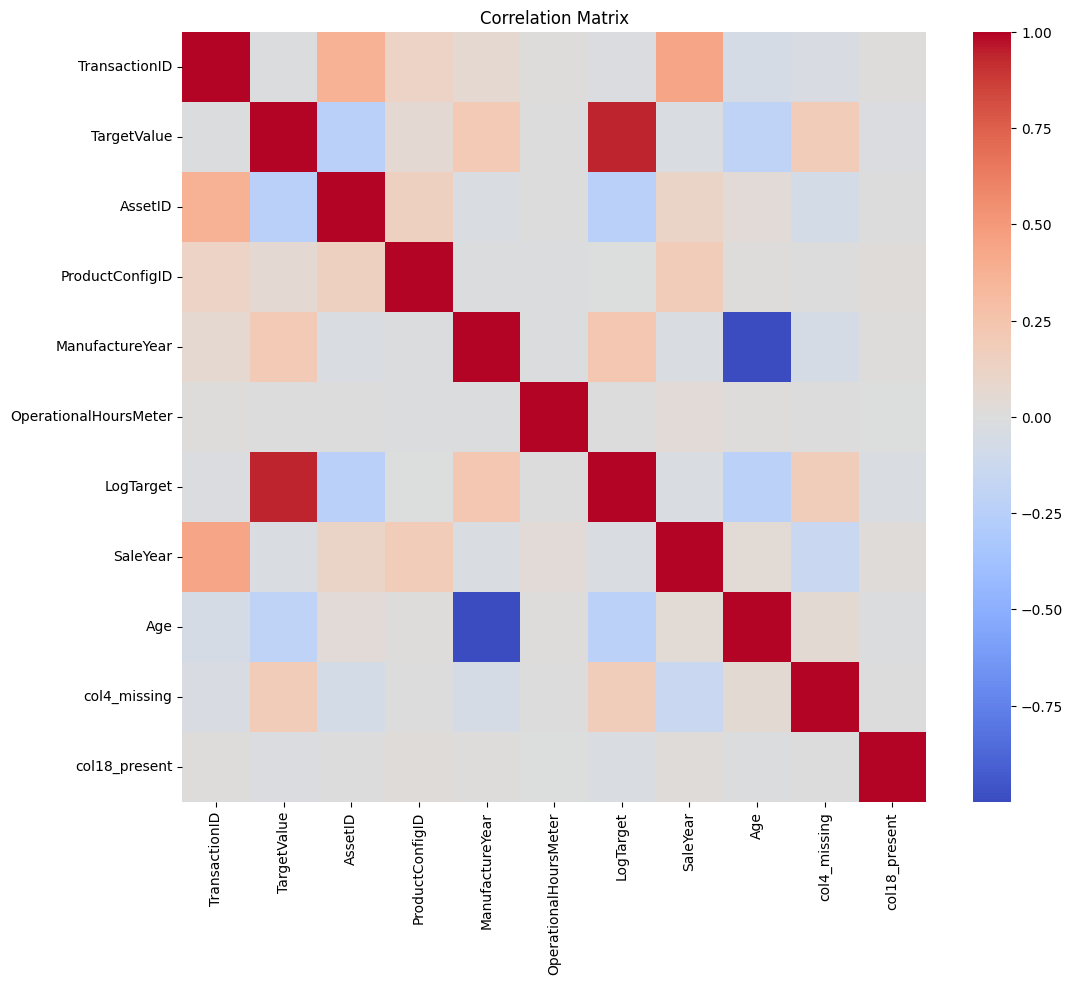

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(train.corr(numeric_only=True),
            cmap="coolwarm",
            center=0)

plt.title("Correlation Matrix")
plt.show()

# Feature Engineering

Based on the EDA findings above, we now construct the features used for modeling.

In [18]:
# AssetAge and SaleYear were already created during EDA (Cell 18) -
# repeated here for clarity as part of the formal feature set

# New: HasSpecData - a general "completeness" signal, since col4/col18-style
# missingness was shown in EDA to be type-driven rather than random, and is
# itself informative rather than noise
spec_cols = ['col4','col5','col6','col7','col8','col9','col11','col13','col14','col18','col19']
train['SpecCompleteness'] = train[spec_cols].notnull().sum(axis=1)

# New: PriceProxy via Spec_BaseClass average (a finer-grained version of
# InventoryGroupDescription, shown in EDA to carry much stronger price signal)
spec_avg = train.groupby('Spec_BaseClass')['TargetValue'].transform('mean')
train['SpecBaseClassAvgPrice'] = spec_avg

print(train[['SpecCompleteness','SpecBaseClassAvgPrice']].describe())

       SpecCompleteness  SpecBaseClassAvgPrice
count     138701.000000          138701.000000
mean           1.331851           41521.874047
std            2.606909           17353.121206
min            0.000000            7500.000000
25%            0.000000           25370.281055
50%            0.000000           42383.452536
75%            0.000000           54235.528942
max            7.000000          135000.000000


In [19]:
# ===========================================
# FEATURE ENGINEERING (continued)
# ===========================================

# SpecCompleteness - count of how many type-specific spec columns are filled in
# (operationalizes the col4/col18 EDA finding: missingness here is type-driven, not random)
spec_cols = ['col4','col5','col6','col7','col8','col9','col11','col13','col14','col18','col19']
train['SpecCompleteness'] = train[spec_cols].notnull().sum(axis=1)

# Spec_BaseClass_TE - a LEAK-SAFE target-encoded version of Spec_BaseClass,
# our strongest categorical predictor (147 categories, 17x price spread - see EDA).
# Using K-Fold target encoding (rather than a single global mean) prevents the
# model from "cheating" by seeing each row's own price baked into its own feature.
from sklearn.model_selection import KFold

train['Spec_BaseClass_TE'] = np.nan
kf = KFold(n_splits=5, shuffle=True, random_state=42)
global_mean = train['TargetValue'].mean()

for tr_idx, val_idx in kf.split(train):
    fold_means = train.iloc[tr_idx].groupby('Spec_BaseClass')['TargetValue'].mean()
    train.loc[train.index[val_idx], 'Spec_BaseClass_TE'] = (
        train.iloc[val_idx]['Spec_BaseClass'].map(fold_means)
    )

# fill any category that didn't appear in a given fold with the overall average
train['Spec_BaseClass_TE'] = train['Spec_BaseClass_TE'].fillna(global_mean)

print(train[['SpecCompleteness', 'Spec_BaseClass_TE']].describe())

       SpecCompleteness  Spec_BaseClass_TE
count     138701.000000      138701.000000
mean           1.331851       41549.807819
std            2.606909       17320.784677
min            0.000000        7600.000000
25%            0.000000       25478.568358
50%            0.000000       42354.936594
75%            0.000000       54384.987893
max            7.000000      134000.000000


# Model Building

## Model 1: Linear Regression

Let us use AGE, InventoryGroupDesription, CabinType, UtilizationTier and FunctionalClassification for predicting our first linear model and check the results using sklearn

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
feature_num = ['Age']
feature_cat = ['InventoryGroupDescription', 'CabinType', 'UtilizationTier', 'FunctionalClassification']
train_model1 = train[feature_num+feature_cat+['TargetValue']].copy()
train_model1['Age']=train['Age'].fillna(train_model1['Age'].median())
train_model1['UtilizationTier']=train['UtilizationTier'].fillna('Unknown')
X = pd.get_dummies(train_model1[feature_num + feature_cat], columns=feature_cat)
y = np.log1p(train_model1['TargetValue'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state = 42)
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
rmsle = np.sqrt(mean_squared_error(y_test, pred))
print("Validation RMSLE: ", rmsle)

Validation RMSLE:  0.4663408122144064


Updated LR

In [21]:
feature_num = ['Age', 'SpecCompleteness', 'Spec_BaseClass_TE']
feature_cat = ['InventoryGroupDescription', 'CabinType', 'UtilizationTier', 'FunctionalClassification']

train_model1 = train[feature_num + feature_cat + ['TargetValue']].copy()
train_model1['Age'] = train_model1['Age'].fillna(train_model1['Age'].median())
train_model1['UtilizationTier'] = train_model1['UtilizationTier'].fillna('Unknown')

X = pd.get_dummies(train_model1[feature_num + feature_cat], columns=feature_cat)
y = np.log1p(train_model1['TargetValue'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
rmsle = np.sqrt(mean_squared_error(y_test, pred))
print("Linear Regression Validation RMSLE:", rmsle)

Linear Regression Validation RMSLE: 0.4263235007924435


In [22]:
# ===========================================
# Model 1B: Linear Regression via sklearn Pipeline
# (same features/target as Model 1, but preprocessing
# is handled through Pipeline + ColumnTransformer
# instead of manual get_dummies/fillna)
# ===========================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

feature_num = ['Age', 'SpecCompleteness', 'Spec_BaseClass_TE']
feature_cat = ['InventoryGroupDescription', 'CabinType', 'UtilizationTier', 'FunctionalClassification']

train_model1b = train[feature_num + feature_cat + ['TargetValue']].copy()

X_1b = train_model1b[feature_num + feature_cat]
y_1b = np.log1p(train_model1b['TargetValue'])

X_1b_train, X_1b_test, y_1b_train, y_1b_test = train_test_split(
    X_1b, y_1b, test_size=0.2, random_state=42
)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_1b = ColumnTransformer([
    ('num', num_pipe, feature_num),
    ('cat', cat_pipe, feature_cat)
])

model1b = Pipeline([
    ('preprocessor', preprocessor_1b),
    ('regressor', LinearRegression())
])

model1b.fit(X_1b_train, y_1b_train)
pred_1b = model1b.predict(X_1b_test)
rmsle_1b = np.sqrt(mean_squared_error(y_1b_test, pred_1b))

print("Model 1B (Pipeline) Validation RMSLE:", rmsle_1b)


Model 1B (Pipeline) Validation RMSLE: 0.4264602486180345


In [23]:
X_1b_train

,Age,SpecCompleteness,Spec_BaseClass_TE,InventoryGroupDescription,CabinType,UtilizationTier,FunctionalClassification
35835,13,0,24086.991063,Track Excavators,EROPS,NaN,"Hydraulic Excavator, Track - 12.0 to 14.0 Metr..."
33687,9,7,71281.394264,Motor Graders,EROPS w AC,NaN,Motorgrader - 145.0 to 170.0 Horsepower
46296,26,0,20026.953748,Track Excavators,EROPS,NaN,"Hydraulic Excavator, Track - 16.0 to 19.0 Metr..."
26487,4,2,25478.568358,Backhoe Loaders,EROPS,Medium,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...
71601,7,0,53409.031330,Track Excavators,EROPS w AC,NaN,"Hydraulic Excavator, Track - 33.0 to 40.0 Metr..."
...,...,...,...,...,...,...,...
110268,5,0,17167.421384,Track Excavators,EROPS,High,"Hydraulic Excavator, Track - 19.0 to 21.0 Metr..."
119879,1010,0,38951.111111,Wheel Loader,OROPS,NaN,Wheel Loader - 175.0 to 200.0 Horsepower
103694,1010,0,42093.750000,Track Excavators,EROPS,NaN,"Hydraulic Excavator, Track - 40.0 to 50.0 Metr..."
131932,7,0,47465.886700,Track Excavators,EROPS w AC,High,"Hydraulic Excavator, Track - 16.0 to 19.0 Metr..."


Correlation Matrix:
                    Age  SpecCompleteness  Spec_BaseClass_TE  TargetValue
Age                1.00              0.01              -0.14        -0.20
SpecCompleteness   0.01              1.00               0.10         0.07
Spec_BaseClass_TE -0.14              0.10               1.00         0.65
TargetValue       -0.20              0.07               0.65         1.00


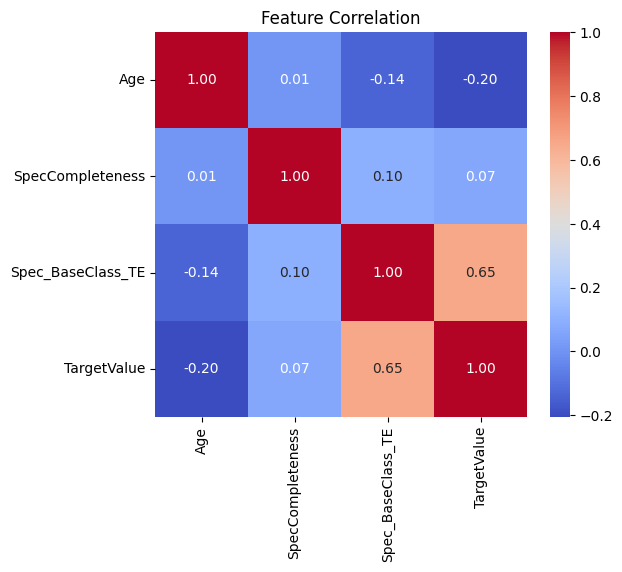

In [24]:
# ===========================================
# Correlation Check for Model 1 Features
# ===========================================

import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features
corr_data = train[['Age', 'SpecCompleteness', 'Spec_BaseClass_TE', 'TargetValue']].copy()

# Correlation matrix
corr = corr_data.corr()

print("Correlation Matrix:")
print(corr.round(2))

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation")
plt.show()

SUBMISSION

## Model 2: Random Forest

Obviously under regression Inventory group description is dominating let us check other models for the same x-y split

In [25]:
from sklearn.ensemble import RandomForestRegressor
rf_model_testing = RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model_testing.fit(X_train_rf, y_train_rf)

rf_pred = rf_model_testing.predict(X_val_rf)
rf_rmsle = np.sqrt(mean_squared_error(y_val_rf, rf_pred))
print("Random Forest Validation RMSLE:", rf_rmsle)

Random Forest Validation RMSLE: 0.2913581286103201


In [26]:
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

rf_pred = rf_model.predict(X_val_rf)
rf_rmsle = np.sqrt(mean_squared_error(y_val_rf, rf_pred))
print("Random Forest Validation RMSLE:", rf_rmsle)

Random Forest Validation RMSLE: 0.2913581286103201


In [27]:
# ===========================================
# FINAL SUBMISSION - Random Forest with engineered features
# ===========================================

# Recompute Age on test (same logic as train)
test['TransactionDate'] = pd.to_datetime(test['TransactionDate'])
test['SaleYear'] = test['TransactionDate'].dt.year
test['Age'] = test['SaleYear'] - test['ManufactureYear']
test.loc[test['Age'] < 0, 'Age'] = np.nan
test.loc[test['Age'] > 60, 'Age'] = np.nan

# Apply same feature engineering used on train
test['SpecCompleteness'] = test[spec_cols].notnull().sum(axis=1)

full_train_means = train.groupby('Spec_BaseClass')['TargetValue'].mean()
test['Spec_BaseClass_TE'] = test['Spec_BaseClass'].map(full_train_means).fillna(global_mean)

test_model1 = test[feature_num + feature_cat].copy()
test_model1['Age'] = test_model1['Age'].fillna(train_model1['Age'].median())
test_model1['UtilizationTier'] = test_model1['UtilizationTier'].fillna('Unknown')

X_test_final = pd.get_dummies(test_model1, columns=feature_cat)
X_test_final = X_test_final.reindex(columns=X.columns, fill_value=0)

# Refit Random Forest on ALL labeled data for the strongest final model
rf_model_final = RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)
rf_model_final.fit(X, y)

test_preds_log = rf_model_final.predict(X_test_final)
test_preds = np.expm1(test_preds_log)

submission = pd.DataFrame({
    'TransactionID': test['TransactionID'],
    'TargetValue': test_preds
})

print("Missing predictions:", submission['TargetValue'].isnull().sum())
print("Prediction range:", submission['TargetValue'].min(), "-", submission['TargetValue'].max())
submission.to_csv('submission.csv', index=False)
submission.head(10)

Missing predictions: 0
Prediction range: 7854.6747872691485 - 134771.45860381692


,TransactionID,TargetValue
0,1139307,75991.758167
1,1139419,68627.647346
2,1139482,25590.123068
3,1139522,28986.723769
4,1139684,11657.353570
5,1139773,38884.907814
6,1139779,23622.494368
7,1139793,46404.473703
8,1139814,80268.016202
9,1139839,15649.475764


## Model 3: LightGBM

Linear Regression and Random Forest both struggled to break below RMSLE 0.30 with the 
limited feature set used so far. Two root causes: (1) the feature set was too narrow — 
omitting strong predictors like Spec_SubClass, SaleMonth, HoursPerYear; (2) Linear 
Regression cannot model non-linear interactions between machine type, age, and spec 
detail, and Random Forest handles missing data less gracefully than gradient boosting.

LightGBM addresses both: it handles categorical features and missing values natively 
(no one-hot encoding needed), learns non-linear interactions via gradient boosting, 
and benefits from early stopping to prevent overfitting.


In [28]:
import lightgbm as lgb
from sklearn.model_selection import KFold

# Fresh load
lgb_train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
lgb_test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')

# ---------------- Feature Engineering ----------------
for df in [lgb_train, lgb_test]:

    # Date features
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
    df['SaleYear'] = df['TransactionDate'].dt.year
    df['SaleMonth'] = df['TransactionDate'].dt.month
    df['SaleQuarter'] = df['TransactionDate'].dt.quarter

    # Clean ManufactureYear
    df.loc[df['ManufactureYear'].isin([1000, 1001]), 'ManufactureYear'] = np.nan

    # Machine age
    df['Age'] = df['SaleYear'] - df['ManufactureYear']
    df.loc[df['Age'] < 0, 'Age'] = np.nan
    df.loc[df['Age'] > 60, 'Age'] = np.nan

    # Hours features
    df['HoursPerYear'] = df['OperationalHoursMeter'] / df['Age']
    df['HoursPerYear'] = df['HoursPerYear'].replace([np.inf, -np.inf], np.nan)

    df['LogHours'] = np.log1p(df['OperationalHoursMeter'].fillna(0))

    # NEW FEATURES
    df['Age_x_Hours'] = df['Age'].fillna(0) * df['LogHours']
    df['AgeSquared'] = df['Age'].fillna(0) ** 2
    df['HoursPerSpec'] = df['LogHours'] / (df['SpecCompleteness'] + 1 if 'SpecCompleteness' in df.columns else 1)

    # Specification completeness
    spec_cols_lgb = [
        'col4','col5','col6','col7','col8','col9',
        'col11','col13','col14','col18','col19'
    ]

    df['SpecCompleteness'] = df[spec_cols_lgb].notnull().sum(axis=1)

    # Recalculate after SpecCompleteness exists
    df['HoursPerSpec'] = df['LogHours'] / (df['SpecCompleteness'] + 1)

    df['HasOperationalHours'] = df['OperationalHoursMeter'].notnull().astype(int)

    df['DescriptorLength'] = df['Spec_FullDescriptor'].astype(str).str.len()

    df['AgeGroup'] = pd.cut(
        df['Age'],
        bins=[0,5,10,15,20,30,60],
        labels=False
    )

    # Categorical columns
    lgb_cats = [
        'InventoryGroupDescription',
        'CabinType',
        'UtilizationTier',
        'FunctionalClassification',
        'Spec_BaseClass',
        'Spec_SubClass',
        'Spec_ReleaseSeries',
        'Spec_VariantModifier',
        'RegionCode',
        'DrivetrainType',
        'InventoryGroupCategory'
    ]

    for c in lgb_cats:
        df[c] = df[c].fillna("Missing").astype("category")

# Target (LOG SCALE)
lgb_train["LogTarget"] = np.log1p(lgb_train["TargetValue"])

print("Feature engineering done")
print(lgb_train.shape, lgb_test.shape)

/tmp/ipykernel_16/2577982456.py:5: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  lgb_train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')


Feature engineering done
(138701, 64) (15000, 62)


In [29]:
lgb_global_mean = lgb_train['TargetValue'].mean()
lgb_kf = KFold(n_splits=5, shuffle=True, random_state=42)

for spec_col in ['Spec_BaseClass', 'Spec_SubClass']:
    te_col = spec_col + '_TE'
    lgb_train[te_col] = np.nan
    for tr_idx, val_idx in lgb_kf.split(lgb_train):
        fold_means = lgb_train.iloc[tr_idx].groupby(spec_col)['TargetValue'].mean()
        lgb_train.loc[lgb_train.index[val_idx], te_col] = (
            lgb_train.iloc[val_idx][spec_col].map(fold_means)
        )
    lgb_train[te_col] = lgb_train[te_col].fillna(lgb_global_mean)
    # For test: use full train means (no labels to leak)
    full_means = lgb_train.groupby(spec_col)['TargetValue'].mean()
    lgb_test[te_col] = lgb_test[spec_col].map(full_means).fillna(lgb_global_mean)

print("Target encoding done")
print(lgb_train[['Spec_BaseClass_TE','Spec_SubClass_TE']].describe())

/tmp/ipykernel_16/2290229186.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fold_means = lgb_train.iloc[tr_idx].groupby(spec_col)['TargetValue'].mean()
/tmp/ipykernel_16/2290229186.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fold_means = lgb_train.iloc[tr_idx].groupby(spec_col)['TargetValue'].mean()
/tmp/ipykernel_16/2290229186.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fold_means = lgb_train.iloc[t

Target encoding done
       Spec_BaseClass_TE  Spec_SubClass_TE
count      138701.000000     138701.000000
mean        41549.807819      41523.681509
std         17320.784677      11935.505912
min          7600.000000       8750.000000
25%         25478.568358      36302.561956
50%         42354.936594      38143.711230
75%         54384.987893      48227.608781
max        134000.000000     100600.000000


/tmp/ipykernel_16/2290229186.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fold_means = lgb_train.iloc[tr_idx].groupby(spec_col)['TargetValue'].mean()
/tmp/ipykernel_16/2290229186.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fold_means = lgb_train.iloc[tr_idx].groupby(spec_col)['TargetValue'].mean()
/tmp/ipykernel_16/2290229186.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  full_means = lgb_train.group

In [30]:
# ===========================================
# HYPERPARAMETER TUNING (RandomizedSearchCV) - LightGBM
# ===========================================
from sklearn.model_selection import RandomizedSearchCV

# Build features here so this cell can run independently
# of the ensemble cell below it
lgb_feature_num = [
    'Age', 'OperationalHoursMeter', 'HoursPerYear', 'SpecCompleteness',
    'HasOperationalHours', 'DescriptorLength', 'Spec_BaseClass_TE',
    'Spec_SubClass_TE', 'SaleYear', 'SaleMonth', 'SaleQuarter',
    'LogHours', 'AgeGroup', 'Age_x_Hours', 'AgeSquared', 'HoursPerSpec'
]
lgb_feature_cat = [
    'InventoryGroupDescription', 'CabinType', 'UtilizationTier',
    'FunctionalClassification', 'Spec_BaseClass', 'Spec_SubClass',
    'Spec_ReleaseSeries', 'Spec_VariantModifier', 'RegionCode',
    'DrivetrainType', 'InventoryGroupCategory'
]
lgb_all_features = lgb_feature_num + lgb_feature_cat

X_lgb = lgb_train[lgb_all_features]
y_lgb = np.log1p(lgb_train['TargetValue'])
X_lgb_test = lgb_test[lgb_all_features]

param_dist = {
    'num_leaves': [31, 63, 95, 127, 159],   #more=overfitting
    'max_depth': [5, 7, 8, 10, 12],         #more=overfitting
    'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08], #more=better but must not overshoot
    'min_child_samples': [10, 20, 30, 40, 50],       #larger reduces overfitting
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0.0, 0.1, 0.3, 0.5, 1.0],
    'reg_lambda': [0.0, 0.1, 0.3, 0.5, 1.0],
}

lgb_base = lgb.LGBMRegressor(
    n_estimators=500,
    random_state=42,
    verbosity=-1
)

search = RandomizedSearchCV(
    lgb_base,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_lgb, y_lgb)

print("Best CV RMSLE:", -search.best_score_)
print("Best params:", search.best_params_)

best_params = search.best_params_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV RMSLE: 0.25421900132728065
Best params: {'subsample': 0.7, 'reg_lambda': 0.3, 'reg_alpha': 0.0, 'num_leaves': 159, 'min_child_samples': 30, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.6}



========== Fold 1 ==========
Fold 1 RMSLE: 0.20259380291650153

========== Fold 2 ==========
Fold 2 RMSLE: 0.20635132220177213

========== Fold 3 ==========
Fold 3 RMSLE: 0.205574554420314

========== Fold 4 ==========
Fold 4 RMSLE: 0.20631590916682863

========== Fold 5 ==========
Fold 5 RMSLE: 0.20471605209606852

Overall OOF RMSLE: 0.20511503791042096


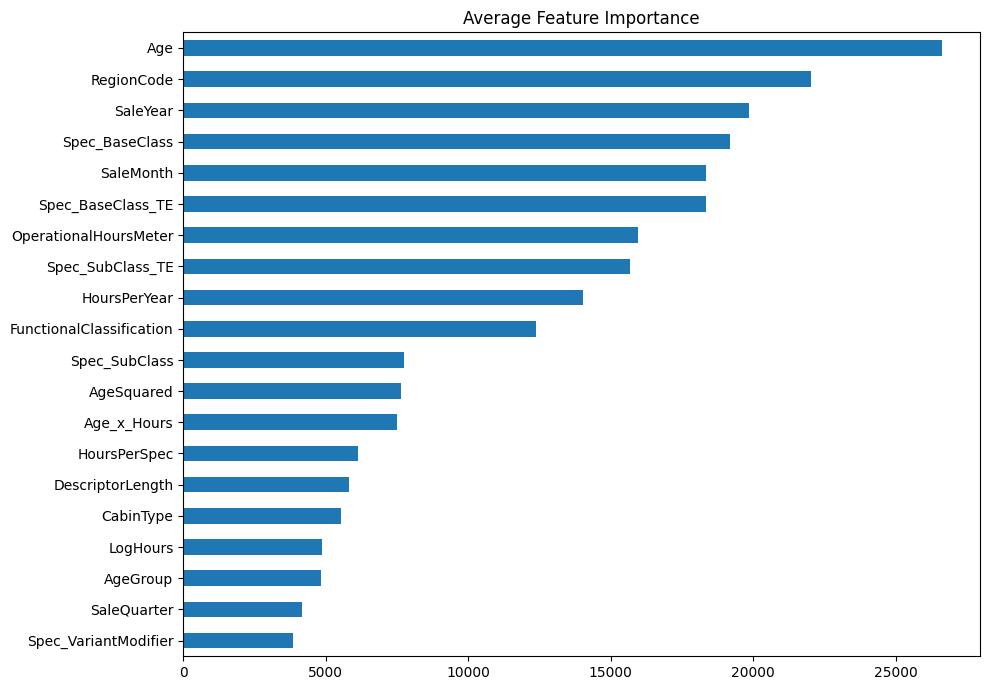

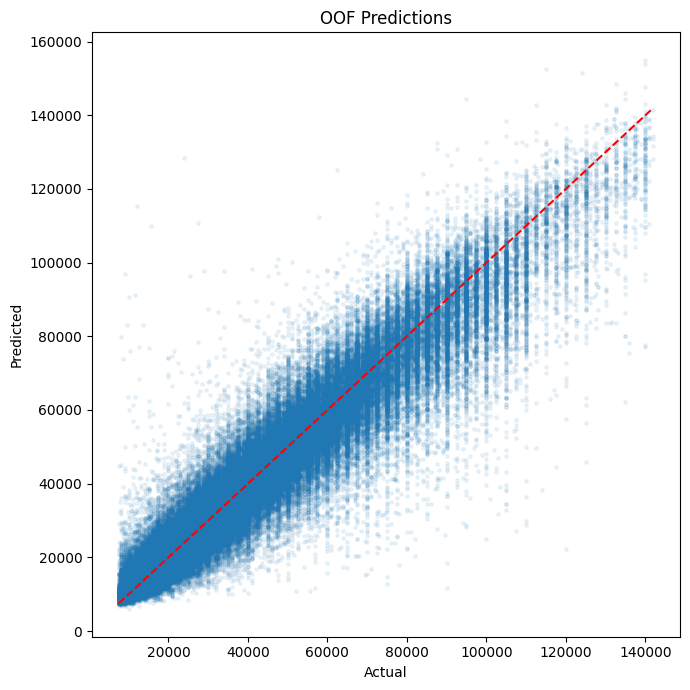

In [31]:
# =====================================================
# 5-FOLD LIGHTGBM ENSEMBLE
# =====================================================

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# -------------------------
# Features
# -------------------------

lgb_feature_num = [
    'Age',
    'OperationalHoursMeter',
    'HoursPerYear',
    'SpecCompleteness',
    'HasOperationalHours',
    'DescriptorLength',
    'Spec_BaseClass_TE',
    'Spec_SubClass_TE',
    'SaleYear',
    'SaleMonth',
    'SaleQuarter',
    'LogHours',
    'AgeGroup',
    'Age_x_Hours',
    'AgeSquared',
    'HoursPerSpec'
]

lgb_feature_cat = [
    'InventoryGroupDescription',
    'CabinType',
    'UtilizationTier',
    'FunctionalClassification',
    'Spec_BaseClass',
    'Spec_SubClass',
    'Spec_ReleaseSeries',
    'Spec_VariantModifier',
    'RegionCode',
    'DrivetrainType',
    'InventoryGroupCategory'
]

lgb_all_features = lgb_feature_num + lgb_feature_cat

X_lgb = lgb_train[lgb_all_features]
y_lgb = np.log1p(lgb_train['TargetValue'])
X_lgb_test = lgb_test[lgb_all_features]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X_lgb))
test_preds = np.zeros(len(X_lgb_test))

feature_importance = np.zeros(len(lgb_all_features))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_lgb), 1):

    print(f"\n========== Fold {fold} ==========")

    X_train = X_lgb.iloc[train_idx]
    y_train = y_lgb.iloc[train_idx]

    X_val = X_lgb.iloc[val_idx]
    y_val = y_lgb.iloc[val_idx]

    model = lgb.LGBMRegressor(
        n_estimators=12000,
        random_state=42 + fold,
        verbosity=-1,
        **best_params
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=lgb_feature_cat,
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=200,
                verbose=False
            )
        ]
    )

    # OOF prediction
    oof_preds[val_idx] = model.predict(
        X_val,
        num_iteration=model.best_iteration_
    )

    # Test prediction
    test_preds += model.predict(
        X_lgb_test,
        raw_score=False,
        num_iteration=model.best_iteration_
    ) / kf.n_splits

    feature_importance += model.feature_importances_.astype(float)

    print(
        f"Fold {fold} RMSLE:",
        np.sqrt(mean_squared_error(y_val, oof_preds[val_idx]))
    )

# -----------------------------------------------------

print("\nOverall OOF RMSLE:",
      np.sqrt(mean_squared_error(y_lgb, oof_preds)))

lgb_test_preds = np.expm1(test_preds)

feature_importance /= kf.n_splits

importance = pd.Series(
    feature_importance,
    index=lgb_all_features
).sort_values()

plt.figure(figsize=(10,7))
importance.tail(20).plot(kind="barh")
plt.title("Average Feature Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,7))
plt.scatter(
    np.expm1(y_lgb),
    np.expm1(oof_preds),
    alpha=0.08,
    s=6
)

mn = np.expm1(y_lgb).min()
mx = np.expm1(y_lgb).max()

plt.plot([mn, mx], [mn, mx], 'r--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("OOF Predictions")
plt.tight_layout()
plt.show()

In [32]:
submission = pd.DataFrame({
    "TransactionID": lgb_test["TransactionID"],
    "TargetValue": lgb_test_preds
})

submission.to_csv("submission.csv", index=False)
submission.head()

,TransactionID,TargetValue
0,1139307,70109.004571
1,1139419,74320.549572
2,1139482,31146.557682
3,1139522,21036.985604
4,1139684,12006.427010


In [33]:
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

In [34]:
# Copy datasets
X_xgb = X_lgb.copy()
X_xgb_test = X_lgb_test.copy()

# Convert categorical columns to integer codes
for col in lgb_feature_cat:
    X_xgb[col] = X_xgb[col].astype("category").cat.codes
    X_xgb_test[col] = X_xgb_test[col].astype("category").cat.codes

y_xgb = y_lgb

In [35]:
xgb_params = {
    "objective": "reg:squarederror",
    "learning_rate": 0.03,
    "max_depth": 8,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "n_estimators": 8000,
    "random_state": 42,
    "tree_method": "hist",
}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_oof = np.zeros(len(X_xgb))
xgb_test_preds = np.zeros(len(X_xgb_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_xgb), 1):

    print(f"\n===== XGBoost Fold {fold} =====")

    X_train = X_xgb.iloc[train_idx]
    y_train = y_xgb.iloc[train_idx]

    X_val = X_xgb.iloc[val_idx]
    y_val = y_xgb.iloc[val_idx]

    model = xgb.XGBRegressor(**xgb_params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    xgb_oof[val_idx] = model.predict(X_val)
    xgb_test_preds += model.predict(X_xgb_test) / kf.n_splits

    rmsle = np.sqrt(mean_squared_error(y_val, xgb_oof[val_idx]))
    print("Fold RMSLE:", rmsle)

print(
    "\nOverall XGB RMSLE:",
    np.sqrt(mean_squared_error(y_xgb, xgb_oof))
)

xgb_test_preds = np.expm1(xgb_test_preds)


===== XGBoost Fold 1 =====
Fold RMSLE: 0.20669267524749285

===== XGBoost Fold 2 =====
Fold RMSLE: 0.21013804485106213

===== XGBoost Fold 3 =====
Fold RMSLE: 0.2417042000683149

===== XGBoost Fold 4 =====
Fold RMSLE: 0.21204577111702363

===== XGBoost Fold 5 =====
Fold RMSLE: 0.2101647899902946

Overall XGB RMSLE: 0.2165332667693249


In [36]:
blend_preds = 0.5 * lgb_test_preds + 0.5 * xgb_test_preds

In [37]:
submission = pd.DataFrame({
    "TransactionID": lgb_test["TransactionID"],
    "TargetValue": blend_preds
})

submission.to_csv("submission_blend.csv", index=False)
submission.head()

,TransactionID,TargetValue
0,1139307,67728.410634
1,1139419,67689.907212
2,1139482,29614.740746
3,1139522,23556.234246
4,1139684,12644.404992


# MILESTONES

In [38]:
# ===========================================
# MILESTONE 2: Feature Engineering, Encoding,
# Correlation Analysis, Scaling, Model Building
# ===========================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Use a NEW variable name - m1_df - so nothing earlier in the notebook can interfere
m1_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
print("Reloaded shape:", m1_df.shape)
print("TargetValue present?", 'TargetValue' in m1_df.columns)

# ---------------------------------------------------------------
# SECTION 1: Feature Engineering
# ---------------------------------------------------------------

m1_df['TransactionDate'] = pd.to_datetime(m1_df['TransactionDate'])
m1_df['TransactionYear'] = m1_df['TransactionDate'].dt.year
m1_df['TransactionQuarter'] = m1_df['TransactionDate'].dt.quarter
m1_df['AssetAge'] = m1_df['TransactionYear'] - m1_df['ManufactureYear']
m1_df['DescriptorLength'] = m1_df['Spec_FullDescriptor'].astype(str).apply(len)
m1_df['HasOperationalHours'] = m1_df['OperationalHoursMeter'].notnull().astype(int)
m1_df['HasVariantModifier'] = m1_df['Spec_VariantModifier'].notnull().astype(int)

print("Shape after feature engineering:", m1_df.shape)

# Q1: Most frequent AssetAge value
print("\nQ1:", m1_df['AssetAge'].value_counts().head(5))

# Q2: Which TransactionQuarter has the highest average TargetValue?
print("\nQ2:", m1_df.groupby('TransactionQuarter')['TargetValue'].mean().sort_values(ascending=False))

# Q3: Max value of DescriptorLength
print("\nQ3:", m1_df['DescriptorLength'].max())

# Q4: How many records have HasOperationalHours == 1?
print("\nQ4:", (m1_df['HasOperationalHours'] == 1).sum())

# Q5: What % of records contain variant info (HasVariantModifier == 1)?
pct_variant = (m1_df['HasVariantModifier'] == 1).mean() * 100
print("\nQ5:", round(pct_variant, 2), "%")

# Q6: Mean of ManufactureYear (raw, unprocessed)
print("\nQ6:", round(m1_df['ManufactureYear'].mean(), 2))

# ---------------------------------------------------------------
# SECTION 2: Encoding
# ---------------------------------------------------------------

m1_df = m1_df.drop(columns=['TransactionDate'])
print("\nShape before encoding:", m1_df.shape)

m1_encoded_check = pd.get_dummies(
    m1_df, columns=['RegionCode', 'CabinType', 'UtilizationTier'], drop_first=True
)
print("Shape after encoding (full one-hot expansion):", m1_encoded_check.shape)

# Q7: How many encoded columns are created from these 3 features?
n_region = m1_df['RegionCode'].nunique() - 1
n_cabin = m1_df['CabinType'].nunique() - 1
n_util = m1_df['UtilizationTier'].nunique() - 1
print("\nQ7:", n_region + n_cabin + n_util)

# ---------------------------------------------------------------
# SECTION 3: Correlation Analysis
# ---------------------------------------------------------------

numeric_cols = m1_df.select_dtypes(include=[np.number]).columns
corr_with_target = m1_df[numeric_cols].corr()['TargetValue'].drop('TargetValue')
print("\nCorrelations with TargetValue:")
print(corr_with_target.sort_values(key=abs, ascending=False))

# Q8: Which feature has the highest ABSOLUTE correlation with TargetValue?
print("\nQ8:", corr_with_target.abs().idxmax(), "-> correlation:", corr_with_target.abs().max())

# ---------------------------------------------------------------
# SECTION 4: Feature Scaling
# ---------------------------------------------------------------

for col in ['ManufactureYear', 'OperationalHoursMeter', 'AssetAge']:
    m1_df[col] = m1_df[col].fillna(m1_df[col].mean())

scaler = StandardScaler()
m1_df[['ManufactureYear', 'OperationalHoursMeter', 'AssetAge']] = scaler.fit_transform(
    m1_df[['ManufactureYear', 'OperationalHoursMeter', 'AssetAge']]
)

print("\nShape after scaling (no column count change):", m1_df.shape)

m1_train, m1_val = train_test_split(m1_df, test_size=0.20, random_state=42)

print("\nQ9 - Training shape:", m1_train.shape)
print("Q10 - Validation shape:", m1_val.shape)

# ---------------------------------------------------------------
# SECTION 5: Model Building
# ---------------------------------------------------------------

features = ['ManufactureYear', 'AssetAge']

model = LinearRegression()
model.fit(m1_train[features], m1_train['TargetValue'])

val_preds = model.predict(m1_val[features])
r2 = r2_score(m1_val['TargetValue'], val_preds)

print("\nQ11 - R^2 score on validation:", round(r2, 4))

/tmp/ipykernel_16/8086817.py:14: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  m1_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')


Reloaded shape: (138701, 50)
TargetValue present? True
Shape after feature engineering: (138701, 56)

Q1: AssetAge
5    12542
4    11438
6    11349
7     9644
3     8694
Name: count, dtype: int64

Q2: TransactionQuarter
1    42873.587453
2    41408.258228
3    40619.200589
4    40562.454024
Name: TargetValue, dtype: float64

Q3: 19

Q4: 82058

Q5: 37.73 %

Q6: 1891.64

Shape before encoding: (138701, 55)
Shape after encoding (full one-hot expansion): (138701, 108)

Q7: 56

Correlations with TargetValue:
AssetID                 -0.238719
HasVariantModifier       0.217434
AssetAge                -0.204698
ManufactureYear          0.204439
DescriptorLength         0.061502
ProductConfigID          0.057265
TransactionQuarter      -0.034442
TransactionYear         -0.024497
TransactionID           -0.012093
HasOperationalHours     -0.009653
OperationalHoursMeter    0.001994
Name: TargetValue, dtype: float64

Q8: AssetID -> correlation: 0.23871903500868297

Shape after scaling (no column co

In [39]:
# ===========================================
# MILESTONE 5
# ===========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

m5 = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')

# Section 1: Feature Engineering
m5['TransactionDate'] = pd.to_datetime(m5['TransactionDate'])
m5['TransactionYear'] = m5['TransactionDate'].dt.year
m5['TransactionMonth'] = m5['TransactionDate'].dt.month
m5['TransactionQuarter'] = m5['TransactionDate'].dt.quarter
m5['ManufactureDecade'] = (m5['ManufactureYear'] // 10) * 10
m5['SpecificationComplexity'] = m5['Spec_FullDescriptor'].astype(str).apply(lambda x: len(x.split()))

# Q1
print("Q1:", m5.groupby('ManufactureDecade')['TargetValue'].mean().sort_values(ascending=False).head(4))
# Q2
print("Q2:", m5['SpecificationComplexity'].max())
# Section 2: Feature Selection
m5_cat = ['DataOriginCode','VendorPartnerID','UtilizationTier',
           'AssetScaleFactor','RegionCode','InventoryGroupCategory','InventoryGroupDescription']
m5_num = [c for c in m5.select_dtypes(include=[np.number]).columns
          if c not in ['TransactionID','AssetID','TargetValue']]
eng = ['TransactionYear','TransactionMonth','TransactionQuarter','ManufactureDecade','SpecificationComplexity']
m5_num = m5_num + [f for f in eng if f not in m5_num]

X_m5 = m5[m5_num + m5_cat].copy()
y_m5 = m5['TargetValue']
print("Q3: Total features:", len(m5_num + m5_cat))

# Section 3: Split FIRST (before preprocessing)
X_m5_train, X_m5_val, y_m5_train, y_m5_val = train_test_split(
    X_m5, y_m5, test_size=0.2, random_state=42
)
print("Train rows:", X_m5_train.shape[0], "Val rows:", X_m5_val.shape[0])
# Section 4: Pipeline and preprocessing
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, m5_num),
    ('cat', cat_pipe, m5_cat)
])

X_m5_train_proc = preprocessor.fit_transform(X_m5_train)
X_m5_val_proc = preprocessor.transform(X_m5_val)
print("Q4: Training shape after preprocessing:", X_m5_train_proc.shape)
# Section 5: SelectKBest
cat_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(m5_cat).tolist()
all_names = [f'num__{c}' for c in m5_num] + [f'cat__{c}' for c in cat_names]

selector = SelectKBest(f_regression, k=100)
X_m5_train_sel = selector.fit_transform(X_m5_train_proc, y_m5_train)
X_m5_val_sel = selector.transform(X_m5_val_proc)

scores = pd.Series(selector.scores_, index=all_names)
selected_mask = selector.get_support()

print("Q5: Highest F-score feature:")
print(scores.sort_values(ascending=False).head(3))

print("\nQ6: Lowest F-score among SELECTED features:")
print(scores[selected_mask].sort_values().head(3))

print("\nQ7: Features REMOVED by SelectKBest (lowest scores):")
print(scores[~selected_mask].sort_values().head(5))
# Section 6: Baseline Random Forest
rf_base = RandomForestRegressor(random_state=42)
rf_base.fit(X_m5_train_sel, y_m5_train)
base_pred = rf_base.predict(X_m5_val_sel)

print("Q8: Baseline RF Validation MAE:", round(mean_absolute_error(y_m5_val, base_pred), 2))
print("Q9: Baseline RF Validation RMSE:", round(np.sqrt(mean_squared_error(y_m5_val, base_pred)), 2))
# Section 7: Hyperparameter Tuning with RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'max_features': ['sqrt']
}
search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_dist, n_iter=4, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_m5_train_sel, y_m5_train)

print("Q10: Best n_estimators:", search.best_params_['n_estimators'])
print("Q11: Best max_depth:", search.best_params_['max_depth'])
print("Q12: Best CV RMSE:", round(-search.best_score_, 2))

tuned_pred = search.best_estimator_.predict(X_m5_val_sel)
print("Q13: Tuned RF MAE:", round(mean_absolute_error(y_m5_val, tuned_pred), 2))
print("Q14: Tuned RF RMSE:", round(np.sqrt(mean_squared_error(y_m5_val, tuned_pred)), 2))

/tmp/ipykernel_16/888019610.py:15: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  m5 = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')


Q1: ManufactureDecade
2010    59560.064935
2000    48659.923834
1990    41559.931040
1940    37500.000000
Name: TargetValue, dtype: float64
Q2: 4
Q3: Total features: 15
Train rows: 110960 Val rows: 27741
Q4: Training shape after preprocessing: (110960, 118)
Q5: Highest F-score feature:
cat__AssetScaleFactor_Mini    12786.040908
num__ManufactureYear           4851.908809
num__ManufactureDecade         4827.766469
dtype: float64

Q6: Lowest F-score among SELECTED features:
cat__RegionCode_Vermont      3.067820
cat__RegionCode_Tennessee    3.089908
cat__VendorPartnerID_RKC     3.093086
dtype: float64

Q7: Features REMOVED by SelectKBest (lowest scores):
cat__RegionCode_Oklahoma      0.032130
num__OperationalHoursMeter    0.078092
cat__RegionCode_Iowa          0.275805
cat__RegionCode_Delaware      0.312799
cat__RegionCode_Kentucky      0.375049
dtype: float64
Q8: Baseline RF Validation MAE: 6072.88
Q9: Baseline RF Validation RMSE: 9164.64
Fitting 3 folds for each of 4 candidates, totallin